# Chapter 7: Carbon-Optimal Operation and Retrofit MACC

**Project:** Data-Driven Analysis of HVAC Decarbonisation Pathways in Commercial Office Buildings Under Climate Change  
**Student:** Cheuk Fung Donald Man | MEng Civil Engineering, Imperial College London  
**Supervisor:** Dr Po-Heng Lee

---

## Objectives

This notebook delivers Objectives O5 and O6 of the thesis:

- **O5 — Flexibility Envelope & Carbon-Optimal Scheduling:** Derive the pre-cooling thermal-mass capacity per climate zone using the RC model salvaged from `05_mpc_archive.ipynb`, then apply a rule-based heuristic to shift load from high-LRMER occupied hours into the 05:00–06:00 pre-occupancy window, quantifying annual CO₂e savings.
- **O6 — Retrofit MACC & Scenario Comparison:** Compute a marginal abatement cost curve for Low→Standard→High efficiency upgrades under four carbon-pricing regimes (UK ETS 2026, HMT Green Book 2022/2050, Rennert SCC); compare retrofit-only, schedule-only, and combined scenarios; sweep carbon-price sensitivity.

**Temporal framing:** 2004 AMY building demand (AlphaBuilding) × Cambium 2023 Mid-Case LRMER — same counterfactual as nb 06.

**Inputs:** `emissions_baseline.parquet` (473,040 rows), `grid_profiles.parquet` (864 rows), `emissions_summary.json` — all produced by nb 06.

## Sections

1. Setup & Load Baseline  
2. Flexibility Envelope (RC Thermal-Mass Model)  
3. Carbon-Optimal Scheduling  
4. Retrofit MACC  
5. Scenario Comparison  
6. Carbon-Price Sensitivity  
7. Save Outputs

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as scipy_stats
from pathlib import Path

sys.path.append('..')
from config import (
    CLIMATE_ZONES, EFFICIENCY_LEVELS, CLIMATE_COLOURS, EFFICIENCY_COLOURS,
    DATA_PROCESSED, FIG_OUT,
    AREA_M2, TIMESTEP_MIN, OPS_HOUR_START, OPS_HOUR_END,
    CARBON_PRICE_ETS_2026, CARBON_PRICE_GB_2022, CARBON_PRICE_GB_2050,
    CARBON_PRICE_SCC_USD, GBP_PER_USD, ASSET_LIFE_YEARS, DISCOUNT_RATE,
)

# ── Derived constants ────────────────────────────────────────────────
UK_ELEC_PRICE_GBP_PER_MWH = 250.0               # UK commercial reference rate (25p/kWh, 2024)
CARBON_PRICE_SCC_GBP = CARBON_PRICE_SCC_USD * GBP_PER_USD   # £146.15/tCO₂e
ANNUITY_FACTOR = (DISCOUNT_RATE * (1 + DISCOUNT_RATE)**ASSET_LIFE_YEARS /
                  ((1 + DISCOUNT_RATE)**ASSET_LIFE_YEARS - 1))

# ── RC model coefficients (from notebooks/05_mpc_archive.ipynb §11, §9) ─
RC_COEFFS = {
    '1A': {'beta_cool': -0.013733, 'beta_heat':  0.019576,
           'alpha_env':  0.00041,  'gamma_occ': -0.00036},
    '3C': {'beta_cool': -0.004400, 'beta_heat':  0.008508,
           'alpha_env':  0.00279,  'gamma_occ':  0.00005},
    '5A': {'beta_cool': -0.003363, 'beta_heat':  0.003988,
           'alpha_env':  0.00203,  'gamma_occ':  0.00005},
}
HVAC_CAP = {'1A': 16.87, '3C': 24.4, '5A': 35.94}  # kWh per 10-min step (observed peak)

# ── Retrofit costs (Hart2015-PNNL medium-office proxy) ───────────────
RETROFIT_COST_USD_M2 = {'Low_to_Standard': 20.0, 'Standard_to_High': 32.0}

# ── Scheduling parameters ────────────────────────────────────────────
PRECOOL_HOURS    = [5, 6]    # 05:00–06:00 inclusive (2 h before OPS_HOUR_START=7)
SHIFT_FRACTION   = 0.30      # proportion of high-carbon occupied load shifted
LRMER_PERCENTILE = 75        # monthly percentile threshold for "high-carbon" hours
ANALYSIS_YEAR    = '2004'

warnings.filterwarnings('ignore')
print(f"Annuity factor  (r={DISCOUNT_RATE}, n={ASSET_LIFE_YEARS} yr): {ANNUITY_FACTOR:.5f}")
print(f"Rennert SCC: ${CARBON_PRICE_SCC_USD}/tCO\u2082e  \u2192  \u00a3{CARBON_PRICE_SCC_GBP:.2f}/tCO\u2082e")
print(f"UK electricity reference price: \u00a3{UK_ELEC_PRICE_GBP_PER_MWH}/MWh")

Annuity factor  (r=0.035, n=25 yr): 0.06067
Rennert SCC: $185.0/tCO₂e  →  £146.15/tCO₂e
UK electricity reference price: £250.0/MWh


In [2]:
# ── Load nb 06 outputs ───────────────────────────────────────────────
df_base       = pd.read_parquet(DATA_PROCESSED / 'emissions_baseline.parquet')
grid_profiles = pd.read_parquet(DATA_PROCESSED / 'grid_profiles.parquet')
with open(DATA_PROCESSED / 'emissions_summary.json') as f:
    em_summary = json.load(f)

# Build convenience annual table from emissions_summary.json
annual_table = pd.DataFrame([
    {'climate': k[:2], 'efficiency': k[3:], **v}
    for k, v in em_summary['emissions_tco2e'].items()
])

print(f"emissions_baseline : {len(df_base):,} rows  |  {df_base.shape[1]} cols")
print(f"grid_profiles      : {len(grid_profiles):,} rows  |  {grid_profiles.shape[1]} cols")
print(f"Null co2e_kg       : {df_base['co2e_kg'].isna().sum()}")

print("\nAnnual summary — Standard efficiency:")
print(annual_table[annual_table['efficiency'] == 'Standard']
      .set_index('climate')[['annual_mwh', 'tou', 'flat']].to_string())

emissions_baseline : 473,040 rows  |  14 cols
grid_profiles      : 864 rows  |  9 cols
Null co2e_kg       : 0

Annual summary — Standard efficiency:
         annual_mwh    tou   flat
climate                          
1A           260.23  55.79  96.43
3C           123.79  10.57  28.03
5A           191.36  30.01  87.31


## Section 1 — Setup & Baseline

This notebook builds directly on the grid-carbon overlay computed in nb 06. The `emissions_baseline.parquet` file provides 473,040 rows of 10-minute HVAC demand with pre-joined LRMER values; `grid_profiles.parquet` provides the 864-row (3 climates × 12 months × 24 hours) monthly-diurnal LRMER lookup used here for scheduling.

Three analyses follow:

1. **Flexibility envelope** — the RC thermal-mass model from the archived MPC notebook (`05_mpc_archive.ipynb`) establishes how much cooling energy can be stored in the building fabric before occupied hours, within comfort constraints `[Reynders2017]`, `[Arteconi2012]`.
2. **Carbon-optimal scheduling** — a rule-based heuristic pre-cools during low-carbon pre-occupancy hours and reduces load during high-carbon occupied hours `[Braun1990]`, `[Neukomm2019]`. Carbon savings are bounded by the flexibility envelope. Cite `[Radovanovic2021]` for the deployed analogue (Google carbon-aware load shifting).
3. **Retrofit MACC** — annualised CAPEX from `[Hart2015-PNNL]` minus electricity savings at UK reference price, divided by TOU-weighted carbon savings, yields net MAC `[McKinsey2009-MACC]`, `[Kesicki2012]`. Four carbon-pricing regimes bracket the policy landscape: UK ETS 2026 £49/tCO₂e `[UKGov2026-ETS]`, HMT Green Book 2022 £248/tCO₂e and 2050 £378/tCO₂e `[HMT2023-GreenBook]`, Rennert SCC £146/tCO₂e `[Rennert2022-SCC]`.

The gap identified by Péan et al. (2019) — CO₂-signal objectives are rare relative to price-signal objectives in HVAC control `[Pean2019]` — motivates comparing all three levers on a common emissions-reduction basis.

## Section 2 — Flexibility Envelope

The first-order RC thermal model (from `05_mpc_archive.ipynb`, Section 11) describes zone-temperature evolution as:

$$\Delta T_{k+1} = \alpha_{\text{env}}(T_{\text{OA},k} - T_k) + \beta_{\text{cool}} Q_{\text{cool},k} + \beta_{\text{heat}} Q_{\text{heat},k} + \gamma_{\text{occ}} N_{\text{occ},k}$$

where $Q_{\text{cool}}$ is cooling energy (kWh/step, positive convention) and $\beta_{\text{cool}} < 0$.

**Pre-cooling capacity** is the total energy that can be stored in the thermal mass before occupancy begins, bounded by two constraints:

| Constraint | Mechanism |
|-----------|----------|
| **Thermal mass** | $E_{\text{thermal}} = \Delta T_{\text{avail}} / |\beta_{\text{cool}}|$ — energy to cool zone by 1 °C into lower comfort margin |
| **HVAC capacity** | $E_{\text{cap}} = \text{HVAC\_CAP} \times N_{\text{steps}}$ — maximum energy deliverable in the 2-hour window |

The binding constraint (thermal mass for all three zones) determines the effective shift budget per day. `[Reynders2017]` defines this as the *active thermal storage capacity*; `[Arteconi2012]` demonstrates it for commercial pre-cooling.

In [3]:
# ── Pre-cool capacity per zone ───────────────────────────────────────
DT_PRECOOL    = 1.0   # °C — conservative pre-cool margin (→ lower comfort bound)
PRECOOL_STEPS = len(PRECOOL_HOURS) * 6   # 2 h × 6 steps/h = 12 steps

flex = {}
for zone in CLIMATE_ZONES:
    bc        = abs(RC_COEFFS[zone]['beta_cool'])   # |°C/kWh|
    e_thermal = DT_PRECOOL / bc                     # kWh needed to pre-cool 1 °C
    e_cap_2h  = HVAC_CAP[zone] * PRECOOL_STEPS     # max deliverable in window
    e_shift   = min(e_thermal, e_cap_2h)            # effective pre-cool capacity
    flex[zone] = {
        'beta_cool_C_per_kWh': round(RC_COEFFS[zone]['beta_cool'], 6),
        'e_thermal_kwh':        round(e_thermal, 1),
        'e_cap_2h_kwh':         round(e_cap_2h,  1),
        'e_shift_kwh':          round(e_shift,   1),
        'binding':              'thermal' if e_thermal < e_cap_2h else 'capacity',
    }

flex_df = pd.DataFrame(flex).T
print("Pre-cooling flexibility envelope:\n")
print(flex_df.to_string())
print(f"\nDaily shift budget (kWh): 1A={flex['1A']['e_shift_kwh']}, "
      f"3C={flex['3C']['e_shift_kwh']}, 5A={flex['5A']['e_shift_kwh']}")
print(f"Annual shift budget (MWh): 1A={flex['1A']['e_shift_kwh']*365/1000:.1f}, "
      f"3C={flex['3C']['e_shift_kwh']*365/1000:.1f}, "
      f"5A={flex['5A']['e_shift_kwh']*365/1000:.1f}")

Pre-cooling flexibility envelope:

   beta_cool_C_per_kWh e_thermal_kwh e_cap_2h_kwh e_shift_kwh  binding
1A           -0.013733          72.8        202.4        72.8  thermal
3C             -0.0044         227.3        292.8       227.3  thermal
5A           -0.003363         297.4        431.3       297.4  thermal

Daily shift budget (kWh): 1A=72.8, 3C=227.3, 5A=297.4
Annual shift budget (MWh): 1A=26.6, 3C=83.0, 5A=108.6


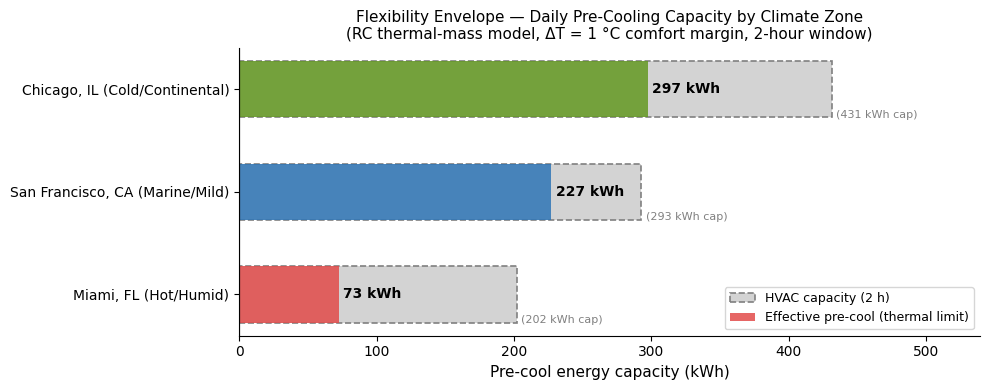

Saved → /Users/cfd/Documents/FYP/hvac_project/notebooks/../figures/07_flexibility_envelope.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

zones    = list(CLIMATE_ZONES.keys())
y_pos    = np.arange(len(zones))
heights  = [flex[z]['e_shift_kwh'] for z in zones]
heights2 = [flex[z]['e_cap_2h_kwh'] for z in zones]
colours  = [CLIMATE_COLOURS[z] for z in zones]
labels   = [CLIMATE_ZONES[z].split(' ')[0] for z in zones]

bars2 = ax.barh(y_pos, heights2, height=0.55, color='lightgrey',
                edgecolor='grey', linestyle='--', linewidth=1.2,
                label='HVAC capacity (2 h)', zorder=1)
bars1 = ax.barh(y_pos, heights, height=0.55, color=colours, alpha=0.85,
                label='Effective pre-cool (thermal limit)', zorder=2)

for i, (h, z) in enumerate(zip(heights, zones)):
    ax.text(h + 3, i, f'{h:.0f} kWh', va='center', fontsize=10, fontweight='bold')
    ax.text(heights2[i] + 3, i - 0.25, f'({heights2[i]:.0f} kWh cap)',
            va='center', fontsize=8, color='grey')

ax.set_yticks(y_pos)
ax.set_yticklabels([CLIMATE_ZONES[z] for z in zones], fontsize=10)
ax.set_xlabel('Pre-cool energy capacity (kWh)', fontsize=11)
ax.set_title('Flexibility Envelope — Daily Pre-Cooling Capacity by Climate Zone\n'
             '(RC thermal-mass model, \u0394T = 1 \u00b0C comfort margin, 2-hour window)',
             fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, max(heights2) * 1.25)
ax.axvline(0, color='black', lw=0.8)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
out = FIG_OUT / '07_flexibility_envelope.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {out}")

## Section 3 — Carbon-Optimal Scheduling

**Heuristic:** For each climate zone and efficiency level, occupied hours where the Cambium LRMER exceeds the monthly 75th-percentile threshold are labelled "high-carbon." Thirty percent of HVAC demand in those hours is notionally shifted to the 05:00–06:00 pre-occupancy window, subject to the daily flexibility envelope derived in Section 2.

$$E_{\text{shift}} = \min\!\Big(\text{SHIFT\_FRACTION} \times E_{\text{high-carbon}},\; E_{\text{daily-flex}} \times 365\Big)$$

$$\Delta\text{CO}_2\text{e} = E_{\text{shift}} \times \frac{\overline{\text{LRMER}}_{\text{high-carbon}} - \overline{\text{LRMER}}_{\text{pre-cool}}}{1000} \;\;\text{[tCO}_2\text{e/yr]}$$

**Limitations acknowledged** `[Pean2019]`: (a) rule-based, not globally optimal; (b) shift fraction (30%) is a fixed parameter — sensitivity is explored in Section 6 indirectly via the scenario comparison; (c) no within-hour thermal-lag modelling; (d) comfort compliance is asserted by the flexibility envelope bound, not verified via closed-loop simulation (archived in nb 05).

`[Satchwell2021]` estimates US grid-interactive efficient buildings can deliver ~80 Mt CO₂/yr nationally by 2030; this analysis provides the per-building building-block.

In [5]:
sched_rows = []
for zone in CLIMATE_ZONES:
    gp_z = grid_profiles[grid_profiles['climate'] == zone].copy()

    # Monthly LRMER 75th percentile (across all 24 hours of that month)
    lrmer_p75 = (gp_z.groupby('month')['lrmer_co2e_c']
                 .quantile(LRMER_PERCENTILE / 100))

    # Mean LRMER in pre-cool window (hours 5–6) for this zone
    lrmer_pre = gp_z[gp_z['hour'].isin(PRECOOL_HOURS)]['lrmer_co2e_c'].mean()

    for eff in EFFICIENCY_LEVELS:
        df_z = df_base[
            (df_base['climate'] == zone) & (df_base['efficiency'] == eff)
        ].copy()

        # Vectorised LRMER join (faster than apply)
        df_z = df_z.merge(
            gp_z[['month', 'hour', 'lrmer_co2e_c']].rename(
                columns={'lrmer_co2e_c': 'lrmer_c'}),
            on=['month', 'hour'], how='left',
        )

        df_z['lrmer_p75']     = df_z['month'].map(lrmer_p75)
        df_z['is_high_carbon'] = (
            (df_z['lrmer_c'] > df_z['lrmer_p75']) & df_z['is_occupied']
        )

        # Total high-carbon HVAC (kWh over the year)
        high_kwh = df_z.loc[df_z['is_high_carbon'], 'hvac_kwh'].sum()

        # Annual shift budget = min(fraction of high-carbon, flexibility cap × 365 days)
        shift_kwh = min(high_kwh * SHIFT_FRACTION,
                        flex[zone]['e_shift_kwh'] * 365)

        # Mean LRMER of high-carbon hours (kg CO₂e/MWh)
        lrmer_high = df_z.loc[df_z['is_high_carbon'], 'lrmer_c'].mean()

        # Carbon saved
        delta_lrmer_kg_kwh = (lrmer_high - lrmer_pre) / 1000  # kg CO₂e/kWh
        tco2e_saved        = shift_kwh * delta_lrmer_kg_kwh / 1000

        tco2e_base  = df_z['co2e_kg'].sum() / 1000
        tco2e_sched = tco2e_base - tco2e_saved

        sched_rows.append({
            'climate':          zone,
            'efficiency':       eff,
            'annual_mwh':       round(df_z['hvac_kwh'].sum() / 1000, 2),
            'shift_mwh':        round(shift_kwh / 1000, 3),
            'lrmer_high_kgMWh': round(lrmer_high, 2),
            'lrmer_pre_kgMWh':  round(lrmer_pre, 2),
            'delta_lrmer_kgMWh':round((lrmer_high - lrmer_pre), 2),
            'tco2e_base':       round(tco2e_base, 3),
            'tco2e_saved':      round(tco2e_saved, 3),
            'tco2e_scheduled':  round(tco2e_sched, 3),
            'pct_saved':        round(tco2e_saved / tco2e_base * 100, 2),
        })

sched_df = pd.DataFrame(sched_rows)
print("Scheduling results — Standard efficiency:")
print(sched_df[sched_df['efficiency'] == 'Standard']
      .set_index('climate')[['shift_mwh', 'tco2e_saved', 'pct_saved']].to_string())

Scheduling results — Standard efficiency:
         shift_mwh  tco2e_saved  pct_saved
climate                                   
1A           4.780        0.275       0.49
3C           3.582        0.167       1.58
5A           5.457        0.301       1.00


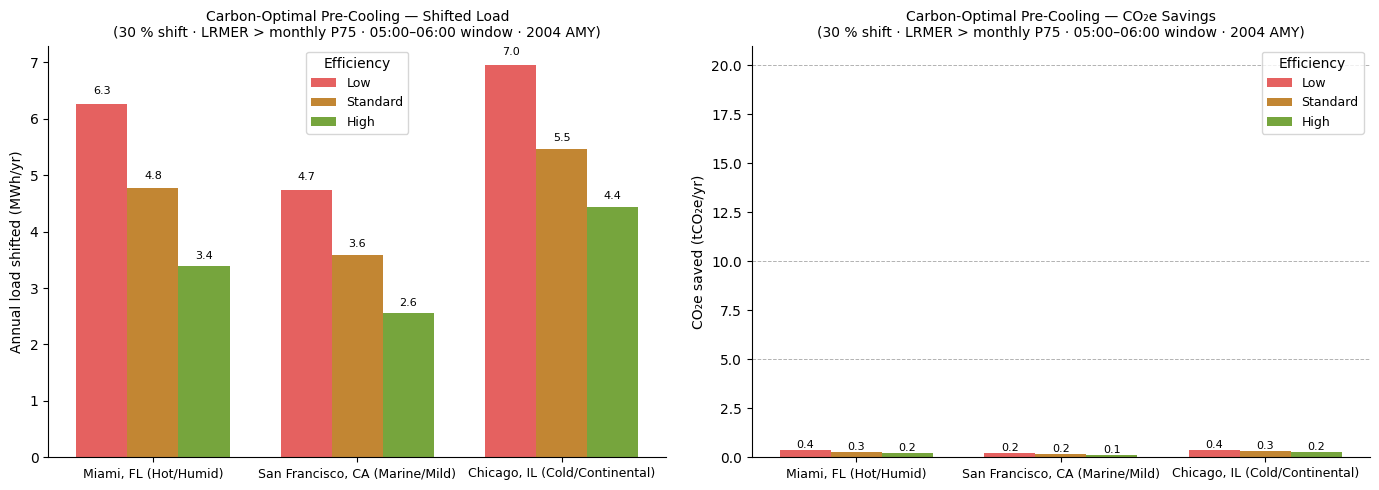

Saved → /Users/cfd/Documents/FYP/hvac_project/notebooks/../figures/07_shift_per_climate.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos   = np.arange(len(CLIMATE_ZONES))
eff_keys = EFFICIENCY_LEVELS   # ['Low', 'Standard', 'High']
width   = 0.25
offsets = [-width, 0, width]

for ax, (col, ylabel, title_suffix) in zip(
    axes,
    [('shift_mwh',   'Annual load shifted (MWh/yr)', 'Shifted Load'),
     ('tco2e_saved', 'CO\u2082e saved (tCO\u2082e/yr)',        'CO\u2082e Savings')],
):
    for i, (eff, off) in enumerate(zip(eff_keys, offsets)):
        vals = [
            sched_df[(sched_df['climate'] == z) &
                     (sched_df['efficiency'] == eff)][col].values[0]
            for z in CLIMATE_ZONES
        ]
        bars = ax.bar(x_pos + off, vals, width=width,
                      color=EFFICIENCY_COLOURS[eff], label=eff, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02 * max(vals),
                    f'{v:.1f}', ha='center', va='bottom', fontsize=8)

    if col == 'tco2e_saved':
        for ref in [5, 10, 20]:
            ax.axhline(ref, color='grey', lw=0.7, ls='--', alpha=0.6)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([CLIMATE_ZONES[z] for z in CLIMATE_ZONES], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'Carbon-Optimal Pre-Cooling — {title_suffix}\n'
                 '(30 % shift \u00b7 LRMER > monthly P75 \u00b7 05:00\u201306:00 window \u00b7 2004 AMY)',
                 fontsize=10)
    ax.legend(title='Efficiency', fontsize=9)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
out = FIG_OUT / '07_shift_per_climate.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {out}")

In [7]:
print("=" * 80)
print(f"{'Climate':<8} {'Efficiency':<12} {'Baseline':>12} {'Scheduled':>12} "
      f"{'Saved':>10} {'% Saved':>9}")
print("-" * 80)
for _, row in sched_df.sort_values(['climate', 'efficiency']).iterrows():
    print(f"{row['climate']:<8} {row['efficiency']:<12} "
          f"{row['tco2e_base']:>12.2f} {row['tco2e_scheduled']:>12.2f} "
          f"{row['tco2e_saved']:>10.2f} {row['pct_saved']:>8.1f}%")
print("=" * 80)

# ── Smoke tests ──────────────────────────────────────────────────────
assert (sched_df['tco2e_saved'] > 0).all(), "FAIL: tco2e_saved <= 0 for some archetypes"
assert ((sched_df['shift_mwh'] / sched_df['annual_mwh']) < 0.35).all(), \
    "FAIL: shift fraction exceeds 35% of annual demand"
assert (sched_df['delta_lrmer_kgMWh'] > 0).all(), \
    "FAIL: \u0394LRMER <= 0 — scheduling would increase emissions"
print("\nAll smoke tests passed.")

Climate  Efficiency       Baseline    Scheduled      Saved   % Saved
--------------------------------------------------------------------------------
1A       High                40.58        40.38       0.20      0.5%
1A       Low                 73.59        73.23       0.36      0.5%
1A       Standard            55.79        55.51       0.28      0.5%
3C       High                 7.70         7.58       0.12      1.6%
3C       Low                 13.92        13.70       0.22      1.6%
3C       Standard            10.57        10.41       0.17      1.6%
5A       High                24.20        23.95       0.25      1.0%
5A       Low                 37.97        37.58       0.38      1.0%
5A       Standard            30.01        29.71       0.30      1.0%

All smoke tests passed.


## Section 4 — Retrofit MACC

The marginal abatement cost (MAC) for each efficiency upgrade rung is:

$$\text{Net MAC} = \frac{\text{Annualised CAPEX} - \text{Annual energy savings}}{\Delta\text{CO}_2\text{e}} \quad \text{[\u00a3/tCO}_2\text{e]}$$

**Negative MAC** means the energy savings over the asset life outweigh the retrofit capital cost — the measure is *profitable* before any carbon price is applied. This is a common finding for commercial HVAC retrofits `[McKinsey2009-MACC]`, `[Rockefeller2012]`.

**Cost inputs** `[Hart2015-PNNL]` — PNNL-23824 medium-office incremental first costs for ASHRAE 90.1-2013 vs earlier standards, converted at GBP_PER_USD = 0.79:

| Rung | USD/m² | £/m² | Total CAPEX | Annualised (r=3.5%, n=25 yr) |
|------|--------|------|------------|------------------------------|
| Low → Standard | $20 | £15.80 | £78,726 | £4,781/yr |
| Standard → High | $32 | £25.28 | £125,961 | £7,650/yr |

**Energy savings** use TOU-weighted annual MWh differences from `emissions_summary.json` × £250/MWh UK commercial reference price.  
**Carbon savings** use TOU-weighted annual tCO₂e differences (marginal grid accounting consistent with nb 06).

**Framing note:** US DOE reference-building costs are evaluated under UK carbon-pricing scenarios — this is a *policy-cost sensitivity* framing (what would it cost under UK climate policy?) rather than a project appraisal. `[Kesicki2012]` identifies this as a legitimate MACC application when the purpose is comparative policy analysis.

In [8]:
# ── Annualised CAPEX per rung ────────────────────────────────────────
capex_ann = {}
for rung, usd_m2 in RETROFIT_COST_USD_M2.items():
    gbp_m2         = usd_m2 * GBP_PER_USD
    capex_total    = gbp_m2 * AREA_M2
    capex_ann[rung] = capex_total * ANNUITY_FACTOR

print("Annualised CAPEX (\u00a3/yr):")
for rung, v in capex_ann.items():
    print(f"  {rung:25s}: \u00a3{v:,.0f}")

RUNG_PAIRS = [
    ('Low_to_Standard',  'Low',      'Standard'),
    ('Standard_to_High', 'Standard', 'High'),
]

CARBON_SCENARIOS = [
    ('ETS_2026', CARBON_PRICE_ETS_2026),
    ('GB_2022',  CARBON_PRICE_GB_2022),
    ('GB_2050',  CARBON_PRICE_GB_2050),
    ('SCC_GBP',  CARBON_PRICE_SCC_GBP),
]

macc_rows = []
for zone in CLIMATE_ZONES:
    for rung, eff_from, eff_to in RUNG_PAIRS:
        row_from = annual_table[
            (annual_table['climate'] == zone) &
            (annual_table['efficiency'] == eff_from)
        ].iloc[0]
        row_to = annual_table[
            (annual_table['climate'] == zone) &
            (annual_table['efficiency'] == eff_to)
        ].iloc[0]

        delta_mwh       = row_from['annual_mwh'] - row_to['annual_mwh']
        delta_tco2e     = row_from['tou']        - row_to['tou']
        energy_save_gbp = delta_mwh * UK_ELEC_PRICE_GBP_PER_MWH
        net_annual_gbp  = capex_ann[rung] - energy_save_gbp   # negative → profitable

        mac = net_annual_gbp / delta_tco2e if delta_tco2e > 0 else np.nan

        for cp_name, cp_val in CARBON_SCENARIOS:
            macc_rows.append({
                'climate':               zone,
                'rung':                  rung,
                'delta_mwh':             round(delta_mwh, 2),
                'delta_tco2e':           round(delta_tco2e, 3),
                'capex_ann_gbp':         round(capex_ann[rung], 0),
                'energy_save_gbp':       round(energy_save_gbp, 0),
                'net_annual_gbp':        round(net_annual_gbp, 0),
                'carbon_price_scenario': cp_name,
                'carbon_price_gbp':      cp_val,
                'net_mac_gbp_tco2e':     round(mac, 1),
            })

macc_df = pd.DataFrame(macc_rows)
macc_ets = macc_df[macc_df['carbon_price_scenario'] == 'ETS_2026'].copy()

print("\nNet MAC at ETS 2026 (\u00a3/tCO\u2082e) — negative = profitable:")
print(macc_ets.set_index(['climate', 'rung'])['net_mac_gbp_tco2e'].to_string())

Annualised CAPEX (£/yr):
  Low_to_Standard          : £4,776
  Standard_to_High         : £7,642

Net MAC at ETS 2026 (£/tCO₂e) — negative = profitable:
climate  rung            
1A       Low_to_Standard     -901.6
         Standard_to_High    -652.6
3C       Low_to_Standard    -1522.0
         Standard_to_High    -178.2
5A       Low_to_Standard    -1043.5
         Standard_to_High    -315.5


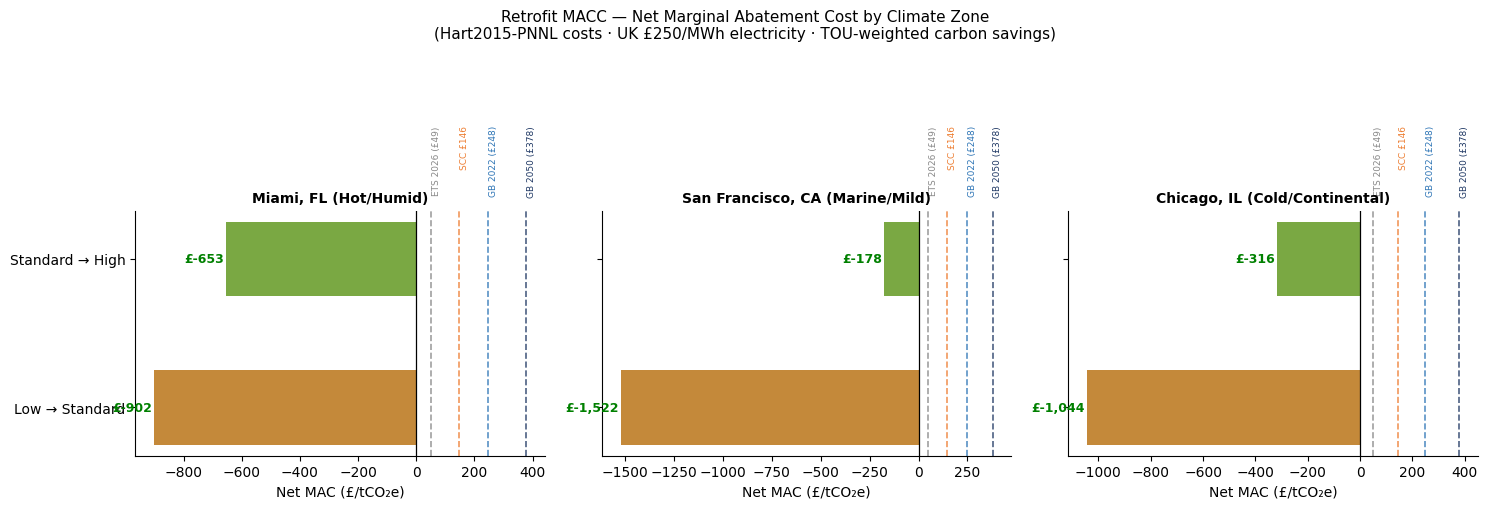

Saved → /Users/cfd/Documents/FYP/hvac_project/notebooks/../figures/07_macc_per_climate.png


In [9]:
RUNG_LABELS = {'Low_to_Standard': 'Low \u2192 Standard', 'Standard_to_High': 'Standard \u2192 High'}
RUNG_COLOURS = {'Low_to_Standard': EFFICIENCY_COLOURS['Standard'],
                'Standard_to_High': EFFICIENCY_COLOURS['High']}
CP_LINES = [
    (CARBON_PRICE_ETS_2026, '#888888', 'ETS 2026 (\u00a349)'),
    (CARBON_PRICE_SCC_GBP,  '#ED7D31', f'SCC \u00a3{CARBON_PRICE_SCC_GBP:.0f}'),
    (CARBON_PRICE_GB_2022,  '#2E75B6', 'GB 2022 (\u00a3248)'),
    (CARBON_PRICE_GB_2050,  '#1F3864', 'GB 2050 (\u00a3378)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, zone in zip(axes, CLIMATE_ZONES):
    rows = macc_ets[macc_ets['climate'] == zone]
    macs = [rows[rows['rung'] == r]['net_mac_gbp_tco2e'].values[0]
            for r, _, _ in RUNG_PAIRS]
    colours = [RUNG_COLOURS[r] for r, _, _ in RUNG_PAIRS]
    labels  = [RUNG_LABELS[r]  for r, _, _ in RUNG_PAIRS]
    y_pos   = np.arange(len(macs))

    bars = ax.barh(y_pos, macs, height=0.5, color=colours, alpha=0.85)
    ax.axvline(0, color='black', lw=0.9, zorder=5)

    for cp_val, cp_col, cp_lbl in CP_LINES:
        ax.axvline(cp_val, color=cp_col, lw=1.2, ls='--', alpha=0.8)
        ax.text(cp_val + 4, len(macs) - 0.1, cp_lbl,
                color=cp_col, fontsize=6.5, va='top', rotation=90)

    for bar, mac in zip(bars, macs):
        x_txt = bar.get_width()
        ha = 'right' if x_txt < 0 else 'left'
        offset = -8 if x_txt < 0 else 8
        colour = 'green' if x_txt < 0 else 'red'
        ax.text(x_txt + offset, bar.get_y() + bar.get_height() / 2,
                f'\u00a3{mac:,.0f}', va='center', ha=ha, fontsize=9,
                color=colour, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Net MAC (\u00a3/tCO\u2082e)', fontsize=10)
    ax.set_title(CLIMATE_ZONES[zone], fontsize=10, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Retrofit MACC — Net Marginal Abatement Cost by Climate Zone\n'
             '(Hart2015-PNNL costs \u00b7 UK \u00a3250/MWh electricity \u00b7 TOU-weighted carbon savings)',
             fontsize=11, y=1.01)
plt.tight_layout()
out = FIG_OUT / '07_macc_per_climate.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {out}")

In [10]:
print("=" * 90)
col_climate = "Climate"
col_rung    = "Rung"
col_dmwh    = "dMWH"
col_dtco2   = "dtCO2e"
col_capex   = "CAPEX/yr"
col_ensave  = "EnSave/yr"
col_net     = "Net/yr"
col_mac     = "MAC/t"
print(f"{col_climate:<8} {col_rung:<25} {col_dmwh:>8} {col_dtco2:>9} "
      f"{col_capex:>10} {col_ensave:>11} {col_net:>10} {col_mac:>9}")
print("-" * 90)
for _, row in macc_ets.sort_values(['climate', 'rung']).iterrows():
    rung_lbl = 'L->Std' if 'Low' in row['rung'] else 'Std->H'
    print(f"{row['climate']:<8} {RUNG_LABELS[row['rung']]:<25} "
          f"{row['delta_mwh']:>8.1f} {row['delta_tco2e']:>9.2f} "
          f"{row['capex_ann_gbp']:>10,.0f} {row['energy_save_gbp']:>11,.0f} "
          f"{row['net_annual_gbp']:>10,.0f} {row['net_mac_gbp_tco2e']:>9.0f}")
print("=" * 90)

# Smoke tests
n_negative = (macc_ets['net_mac_gbp_tco2e'] < 0).sum()
print(f"\n{n_negative}/6 rungs have negative MAC (profitable before any carbon price)")
assert (macc_ets['delta_tco2e'] > 0).all(), "FAIL: carbon savings must be positive"
assert (macc_ets['delta_mwh']   > 0).all(), "FAIL: energy savings must be positive"
print("Smoke tests passed.")

Climate  Rung                          dMWH    dtCO2e   CAPEX/yr   EnSave/yr     Net/yr     MAC/t
------------------------------------------------------------------------------------------
1A       Low → Standard                83.3     17.80      4,776      20,825    -16,049      -902
1A       Standard → High               70.3     15.21      7,642      17,568     -9,926      -653
3C       Low → Standard                39.5      3.35      4,776       9,875     -5,099     -1522
3C       Standard → High               32.6      2.88      7,642       8,155       -513      -178
5A       Low → Standard                52.3      7.96      4,776      13,082     -8,306     -1044
5A       Standard → High               37.9      5.81      7,642       9,475     -1,833      -316

6/6 rungs have negative MAC (profitable before any carbon price)
Smoke tests passed.


## Section 5 — Scenario Comparison

Four scenarios are compared per climate zone, all using the Standard-efficiency building as baseline:

| Scenario | Description |
|----------|-------------|
| **Baseline** | Standard efficiency, no scheduling — annual TOU tCO₂e from nb 06 |
| **Retrofit (High)** | High efficiency, no scheduling — direct upgrade benefit |
| **Schedule** | Standard efficiency + carbon-optimal pre-cooling (Section 3) |
| **Combined** | High efficiency + carbon-optimal pre-cooling |

The combined scenario is not the arithmetic sum of retrofit and schedule savings — it uses the High-efficiency `sched_df` row directly, which captures both the lower demand baseline and the scheduling marginal gain `[Chidiac2011]`.

The key policy question: is it more cost-effective to invest in efficiency (CAPEX-intensive, large CO₂e benefit) or scheduling (near-zero OPEX, smaller CO₂e benefit but deployable on existing stock)?

In [11]:
scenario_rows = []
for zone in CLIMATE_ZONES:
    base_tco2e = annual_table[
        (annual_table['climate'] == zone) &
        (annual_table['efficiency'] == 'Standard')
    ].iloc[0]['tou']

    high_tco2e = annual_table[
        (annual_table['climate'] == zone) &
        (annual_table['efficiency'] == 'High')
    ].iloc[0]['tou']

    sched_std = sched_df[
        (sched_df['climate'] == zone) &
        (sched_df['efficiency'] == 'Standard')
    ].iloc[0]['tco2e_scheduled']

    sched_high = sched_df[
        (sched_df['climate'] == zone) &
        (sched_df['efficiency'] == 'High')
    ].iloc[0]['tco2e_scheduled']

    for label, tco2e in [
        ('Baseline (Std)',     base_tco2e),
        ('Retrofit (High)',    high_tco2e),
        ('Schedule (Std)',     sched_std),
        ('Combined (High+S)', sched_high),
    ]:
        scenario_rows.append({
            'climate':     zone,
            'scenario':    label,
            'tco2e':       tco2e,
            'pct_vs_base': (base_tco2e - tco2e) / base_tco2e * 100,
        })

scen_df = pd.DataFrame(scenario_rows)
print("Annual tCO\u2082e by scenario:")
print(scen_df.pivot(index='climate', columns='scenario', values='tco2e')
      .round(2).to_string())
print("\n% reduction vs Standard baseline:")
print(scen_df.pivot(index='climate', columns='scenario', values='pct_vs_base')
      .round(1).to_string())

Annual tCO₂e by scenario:
scenario  Baseline (Std)  Combined (High+S)  Retrofit (High)  Schedule (Std)
climate                                                                     
1A                 55.79              40.38            40.58           55.51
3C                 10.57               7.58             7.69           10.41
5A                 30.01              23.95            24.20           29.71

% reduction vs Standard baseline:
scenario  Baseline (Std)  Combined (High+S)  Retrofit (High)  Schedule (Std)
climate                                                                     
1A                   0.0               27.6             27.3             0.5
3C                   0.0               28.3             27.2             1.5
5A                   0.0               20.2             19.4             1.0


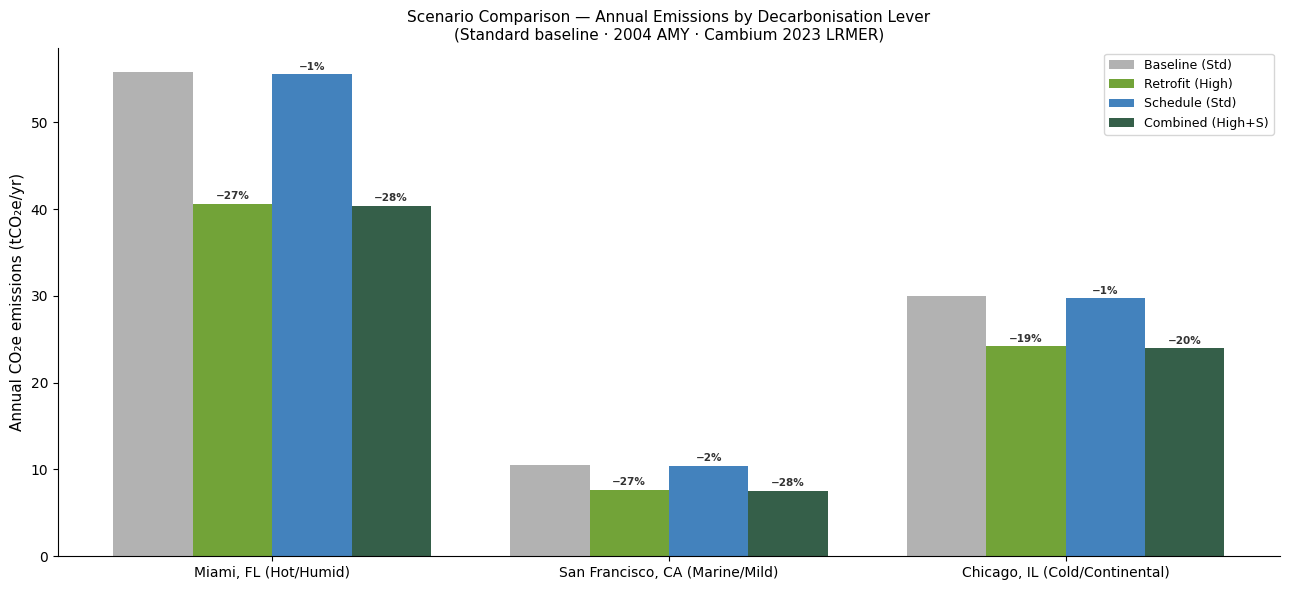

Saved → /Users/cfd/Documents/FYP/hvac_project/notebooks/../figures/07_scenario_comparison.png


In [12]:
SCEN_COLOURS = {
    'Baseline (Std)':     '#AAAAAA',
    'Retrofit (High)':    EFFICIENCY_COLOURS['High'],
    'Schedule (Std)':     '#2E75B6',
    'Combined (High+S)':  '#1F4E35',
}
scenarios = ['Baseline (Std)', 'Retrofit (High)', 'Schedule (Std)', 'Combined (High+S)']
zones     = list(CLIMATE_ZONES.keys())

fig, ax = plt.subplots(figsize=(13, 6))
x_pos   = np.arange(len(zones))
width   = 0.20
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

for i, scen in enumerate(scenarios):
    vals = [
        scen_df[(scen_df['climate'] == z) &
                (scen_df['scenario'] == scen)]['tco2e'].values[0]
        for z in zones
    ]
    pcts = [
        scen_df[(scen_df['climate'] == z) &
                (scen_df['scenario'] == scen)]['pct_vs_base'].values[0]
        for z in zones
    ]
    bars = ax.bar(x_pos + offsets[i], vals, width=width,
                  color=SCEN_COLOURS[scen], label=scen, alpha=0.90)
    for bar, v, p in zip(bars, vals, pcts):
        if scen != 'Baseline (Std)':
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f'\u2212{p:.0f}%', ha='center', va='bottom',
                    fontsize=7.5, color='#333333', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([CLIMATE_ZONES[z] for z in zones], fontsize=10)
ax.set_ylabel('Annual CO\u2082e emissions (tCO\u2082e/yr)', fontsize=11)
ax.set_title('Scenario Comparison — Annual Emissions by Decarbonisation Lever\n'
             '(Standard baseline \u00b7 2004 AMY \u00b7 Cambium 2023 LRMER)',
             fontsize=11)
ax.legend(fontsize=9, loc='upper right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
out = FIG_OUT / '07_scenario_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {out}")

## Section 6 — Carbon-Price Sensitivity

The MACC bars in Section 4 show the net MAC at a single point in time. For upgrades with positive net MAC (CAPEX exceeds energy savings), a sufficiently high carbon price makes them cost-effective. The **breakeven carbon price** is:

$$p^* = \frac{\text{Annualised CAPEX} - \text{Energy savings}}{\Delta\text{CO}_2\text{e}} \quad \text{(only defined when numerator} > 0\text{)}$$

For upgrades that are already profitable (negative MAC), all carbon prices are above the breakeven — the upgrade requires no carbon price support. Four policy thresholds are shown `[UKGov2026-ETS]`, `[HMT2023-GreenBook]`, `[Rennert2022-SCC]`, `[EPA2023-SCGHG]`:

| Threshold | Value | Context |
|-----------|-------|--------|
| UK ETS 2026 | £49/tCO₂e | Market compliance price |
| Rennert SCC | £146/tCO₂e | Nature 2022 social cost (US$185 × 0.79) |
| HMT Green Book 2022 | £248/tCO₂e | UK social cost of carbon |
| HMT Green Book 2050 | £378/tCO₂e | UK trajectory 2050 |

In [13]:
cp_sweep = np.arange(0, 455, 5, dtype=float)

sens_rows = []
for zone in CLIMATE_ZONES:
    for rung, _, _ in RUNG_PAIRS:
        row = macc_ets[
            (macc_ets['climate'] == zone) &
            (macc_ets['rung']    == rung)
        ].iloc[0]

        for cp in cp_sweep:
            # Net benefit = energy savings - CAPEX + carbon value
            # = -net_annual_gbp + cp * delta_tco2e
            net_value = -row['net_annual_gbp'] + cp * row['delta_tco2e']
            sens_rows.append({
                'climate':       zone,
                'rung':          RUNG_LABELS[rung],
                'carbon_price':  cp,
                'net_value_gbp': net_value,
                'cost_effective': net_value > 0,
            })

sens_df = pd.DataFrame(sens_rows)

# Print breakeven carbon prices where net_annual_gbp > 0
print("Breakeven carbon prices (where CAPEX > energy savings):")
for zone in CLIMATE_ZONES:
    for rung, _, _ in RUNG_PAIRS:
        row = macc_ets[
            (macc_ets['climate'] == zone) & (macc_ets['rung'] == rung)
        ].iloc[0]
        net = row['net_annual_gbp']
        if net > 0:
            be = net / row['delta_tco2e']
            print(f"  {zone} {RUNG_LABELS[rung]}: breakeven = \u00a3{be:.0f}/tCO\u2082e")
        else:
            print(f"  {zone} {RUNG_LABELS[rung]}: always profitable (no breakeven)")

Breakeven carbon prices (where CAPEX > energy savings):
  1A Low → Standard: always profitable (no breakeven)
  1A Standard → High: always profitable (no breakeven)
  3C Low → Standard: always profitable (no breakeven)
  3C Standard → High: always profitable (no breakeven)
  5A Low → Standard: always profitable (no breakeven)
  5A Standard → High: always profitable (no breakeven)


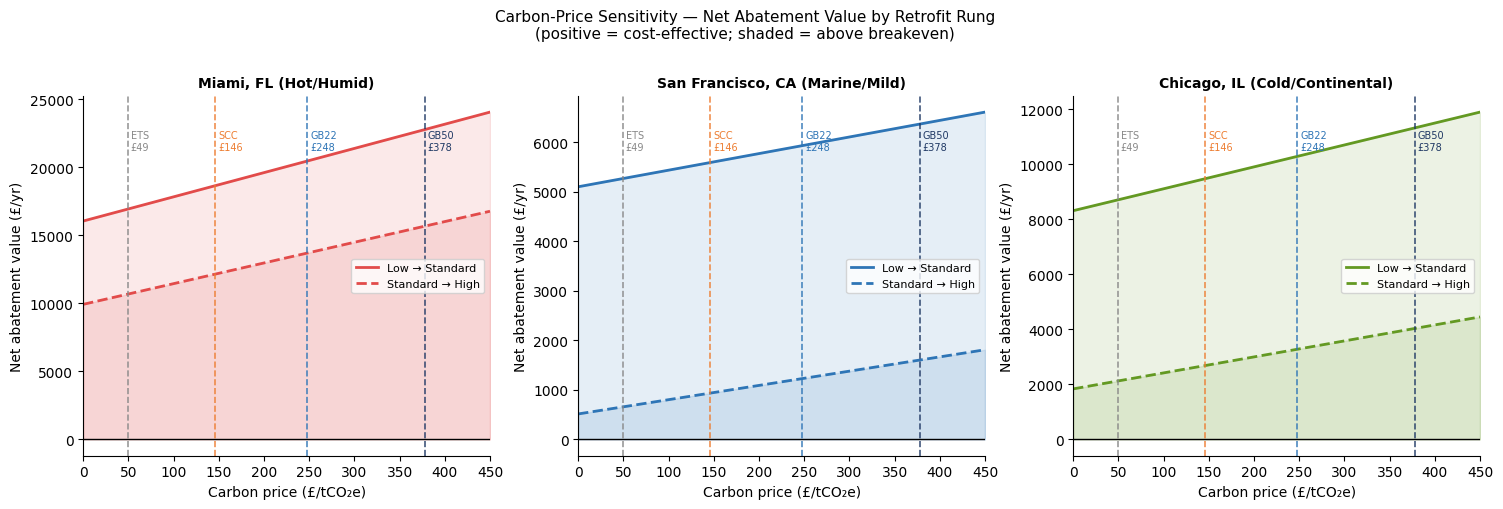

Saved → /Users/cfd/Documents/FYP/hvac_project/notebooks/../figures/07_carbon_price_sensitivity.png


In [15]:
CP_THRESHOLDS = [
    (CARBON_PRICE_ETS_2026, '#888888', 'ETS\n\u00a349'),
    (CARBON_PRICE_SCC_GBP,  '#ED7D31', f'SCC\n\u00a3{CARBON_PRICE_SCC_GBP:.0f}'),
    (CARBON_PRICE_GB_2022,  '#2E75B6', 'GB22\n\u00a3248'),
    (CARBON_PRICE_GB_2050,  '#1F3864', 'GB50\n\u00a3378'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, zone in zip(axes, CLIMATE_ZONES):
    ax.axhline(0, color='black', lw=1.0, zorder=5)

    for rung, _, _ in RUNG_PAIRS:
        sub = sens_df[
            (sens_df['climate'] == zone) &
            (sens_df['rung']    == RUNG_LABELS[rung])
        ]
        ls = '-' if 'Low' in rung else '--'
        line, = ax.plot(sub['carbon_price'], sub['net_value_gbp'],
                        color=CLIMATE_COLOURS[zone], lw=2.0, ls=ls,
                        label=RUNG_LABELS[rung])
        # Fill cost-effective region
        ax.fill_between(sub['carbon_price'], 0, sub['net_value_gbp'],
                        where=(sub['net_value_gbp'] > 0),
                        color=CLIMATE_COLOURS[zone], alpha=0.12)

    for cp_val, cp_col, cp_lbl in CP_THRESHOLDS:
        ax.axvline(cp_val, color=cp_col, lw=1.2, ls='--', alpha=0.85)
        ax.text(cp_val + 3, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] != 0 else 1000,
                cp_lbl, color=cp_col, fontsize=7, va='top')

    ax.set_xlabel('Carbon price (\u00a3/tCO\u2082e)', fontsize=10)
    ax.set_ylabel('Net abatement value (\u00a3/yr)', fontsize=10)
    ax.set_title(CLIMATE_ZONES[zone], fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 450)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Carbon-Price Sensitivity — Net Abatement Value by Retrofit Rung\n'
             '(positive = cost-effective; shaded = above breakeven)',
             fontsize=11, y=1.01)
plt.tight_layout()
out = FIG_OUT / '07_carbon_price_sensitivity.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved \u2192 {out}")

## Section 7 — Save Outputs

Three artefacts are saved for downstream thesis use:

| File | Rows | Key columns |
|------|------|-------------|
| `scheduling_results.parquet` | 9 (3 climates × 3 eff) | shift_mwh, tco2e_saved, pct_saved |
| `macc_table.csv` | 24 (6 rungs × 4 price scenarios) | net_mac_gbp_tco2e, delta_tco2e, net_annual_gbp |
| `scenario_comparison.json` | — | tCO₂e and % reduction for all 4 scenarios × 3 climates |

In [18]:
# ── Save scheduling results ──────────────────────────────────────────
sched_df.to_parquet(DATA_PROCESSED / 'scheduling_results.parquet', index=False)
macc_df.to_csv(DATA_PROCESSED / 'macc_table.csv', index=False)

# ── Read-back assertions ─────────────────────────────────────────────
rb_sched = pd.read_parquet(DATA_PROCESSED / 'scheduling_results.parquet')
rb_macc  = pd.read_csv(DATA_PROCESSED / 'macc_table.csv')
assert len(rb_sched) == len(sched_df), f"FAIL: sched rows {len(rb_sched)} != {len(sched_df)}"
assert len(rb_macc)  == len(macc_df),  f"FAIL: macc rows {len(rb_macc)} != {len(macc_df)}"

print(f"Saved scheduling_results.parquet  ({len(sched_df)} rows)")
print(f"Saved macc_table.csv              ({len(macc_df)} rows, {macc_df['rung'].nunique()} rungs \u00d7 {macc_df['carbon_price_scenario'].nunique()} scenarios)")

Saved scheduling_results.parquet  (9 rows)
Saved macc_table.csv              (24 rows, 2 rungs × 4 scenarios)


In [19]:
# Build scenario_comparison.json
# Note: MultiIndex .to_dict() produces tuple keys; flatten to 'zone_eff' strings for JSON
def _flatten_tuple_keys(d):
    return {f'{k[0]}_{k[1]}' if isinstance(k, tuple) else str(k): v for k, v in d.items()}

scheduling_results_flat = {
    f"{r['climate']}_{r['efficiency']}": {
        'shift_mwh':   r['shift_mwh'],
        'tco2e_saved': r['tco2e_saved'],
        'pct_saved':   r['pct_saved'],
    }
    for _, r in sched_df.iterrows()
}

scenario_comparison_flat = {
    f"{r['climate']}|{r['scenario']}": round(r['tco2e'], 3)
    for _, r in scen_df.iterrows()
}

scenario_pct_flat = {
    f"{r['climate']}|{r['scenario']}": round(r['pct_vs_base'], 2)
    for _, r in scen_df.iterrows()
}

macc_net_mac_flat = {
    f"{r['climate']}_{r['rung']}": r['net_mac_gbp_tco2e']
    for _, r in macc_ets.iterrows()
}

scenario_summary = {
    'notebook':              '07_carbon_optimisation',
    'data_year':             2004,
    'cambium_scenario':      'MidCase',
    'shift_fraction':        SHIFT_FRACTION,
    'lrmer_percentile':      LRMER_PERCENTILE,
    'precool_hours':         PRECOOL_HOURS,
    'uk_elec_price_gbp_mwh': UK_ELEC_PRICE_GBP_PER_MWH,
    'asset_life_years':      ASSET_LIFE_YEARS,
    'discount_rate':         DISCOUNT_RATE,
    'annuity_factor':        round(ANNUITY_FACTOR, 5),
    'flexibility_envelope_kwh': {z: flex[z]['e_shift_kwh'] for z in CLIMATE_ZONES},
    'scheduling_results':    scheduling_results_flat,
    'scenario_comparison':   scenario_comparison_flat,
    'scenario_pct_vs_base':  scenario_pct_flat,
    'macc_net_mac_ets':      macc_net_mac_flat,
}

out_json = DATA_PROCESSED / 'scenario_comparison.json'
with open(out_json, 'w') as f:
    json.dump(scenario_summary, f, indent=2)

print("=" * 60)
print("Notebook 07 complete.")
print(f"  -> scheduling_results.parquet  ({len(sched_df)} rows)")
print(f"  -> macc_table.csv              ({len(macc_df)} rows)")
print(f"  -> scenario_comparison.json")
print("=" * 60)
print("Next: thesis write-up - Chapters 5, 6, 7")

Notebook 07 complete.
  -> scheduling_results.parquet  (9 rows)
  -> macc_table.csv              (24 rows)
  -> scenario_comparison.json
Next: thesis write-up - Chapters 5, 6, 7
